In [22]:
import sys 
sys.path.append("/home/feity/cryoem/")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import torch
import importlib 
import modules
import data
import modules
import postprocess 

import pickle
importlib.reload(data)

<module 'data' from '/home/feity/cryoem/data.py'>

In [83]:
with open(  "/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl", "rb") as f:
    res = pickle.load(f)
res.keys()

dict_keys(['annotations', 'masks', 'bboxes', 'mapclass', 'mrc_shape', 'mrc_path'])

In [85]:
res["mapclass"]

{'ribosome': 0}

In [2]:
# load model
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_final/fold1", "stage3/epoch=6-total_validate_loss=1.1811.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold2_ribo", "stage3/epoch=7-total_validate_loss=0.0677.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_ribo_10", "stage3/epoch=7-total_validate_loss=0.0645.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold2_ribo", "stage2/last.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_mrc_hsp60/fold1", "stage2/epoch=8-total_validate_loss=0.2156.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/whole_ribo_gap1", "stage3/epoch=5-total_validate_loss=0.0273.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_mrc_hsp60/test2", "stage3/epoch=6-total_validate_loss=0.0343.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold2_ribo", "stage2/last.ckpt")
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_ribo", "stage2/last.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_ribo_039", "stage2/epoch=7-total_validate_loss=0.1813.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_mrc_hsp60/test2", "stage3/epoch=6-total_validate_loss=0.0343.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_final/fold1_stage3_new", "epoch=4-total_validate_loss=0.9694.ckpt")
# # model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_mrc_hsp60/fold2", "stage3/epoch=7-total_validate_loss=0.0256.ckpt")
model = model.eval() 

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([1]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([1, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model at stage  stage 1
model with output classes 2
model receiving class weights tensor([1.0000, 0.6000])
using consistency regularization coef 0.5


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/utils.py:1094: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be all

incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


/home/feity/cryoem/utils.py:1132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [24]:
# build test dataset and generate dataframe
# Note: make sure the gap is consistent with the model training
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092018.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092018.pkl", 
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/24092017_ribo.pkl",
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl",
    norm="hist",
    reshape=800,
    map_class={"ribosome":0 },
    gap=1,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    filtermin=0
)
# dataset = data.TestDatasetMrc(
#     # "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc",
#     # "/data/transformer_project/transforemer_model/train_data/TS_031/tomo/TS_031.mrc_10.30Apx.mrc",
#     norm="hist",
#     reshape=800,
#     # transform=data.getConstantTransform(),
#     length_for_average=3,
#     gap = 1
# )

# dataset = data.TestDatasetMrc(
#         # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl",
#         "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/tomo/"
#         + "24092002_9.62Apx.mrc",
#         norm="hist",
#         reshape=800,
    #     length_for_average=3,
    #     gap=1,
    # )
model = model.cpu()
df, graphs = postprocess.generatedf(model, dataset, gap = 1, columns=["ribo", "None"], filter_prob=0.2)
# df, graphs = postprocess.generatedf(model, dataset, gap = 1, columns=["hsp60", "None"], filter_prob=0.20)
# df, graphs = postprocess.generatedf(model, dataset, gap = 5, columns=["ribo", "mitochondria", "nucleus", "endoplasmic_reticulum_or_Golgi", "None"])

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl
dataset map classes:  {'ribosome': 0}
dataset length: 283


 75%|███████▍  | 212/283 [01:44<00:42,  1.67it/s]

100%|██████████| 283/283 [02:27<00:00,  1.92it/s]


finish dataset
build graph
prepare df


In [25]:
with open("/home/feity/cryoem/temp/ribo/TS031/graphs.pkl", "wb") as f:
    pickle.dump(graphs, f)

In [5]:
df["label.y"] = graphs[0].y
df["label.y"].value_counts()

label.y
4    18524
0     3370
Name: count, dtype: int64

In [194]:
dataset = data.TestDatasetMrc(
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl", 
    "/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2/24092009_9.62Apx.mrc", 
    norm="hist",
    reshape=800,
    length_for_average=3,
    gap = 1
)


test dataset


In [ ]:
import os
l = ["24092002_9.62Apx.mrc", "24092013_9.62Apx.mrc", "24092016_9.62Apx.mrc", "24092020_9.62Apx.mrc", "24092024_9.62Apx.mrc", "24092026_9.62Apx.mrc", "24092030_9.62Apx.mrc",
     "24092009_9.62Apx.mrc", "24092014_9.62Apx.mrc", "24092017_9.62Apx.mrc", "24092023_9.62Apx.mrc", "24092025_9.62Apx.mrc", "24092029_9.62Apx.mrc", "24092031_9.62Apx.mrc"]
model = model.cpu()
for i in l:
    if f"home/feity/cryoem/temp/results/%s_gap1_new.pkl"%i.split(".")[0] in os.listdir("/home/feity/cryoem/temp/results/"):
        continue
    dataset2 = data.TestDatasetMrc(
    f"/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2/{i}",
    norm="hist",
    reshape=800,
    length_for_average=3,
    gap = 1
)
    df2, graphs2 = postprocess.generatedf(model, dataset2, gap=1, columns=["ribo", "None"], empty=1, num_classes=1, filter_prob=0.2)
    with open("/home/feity/cryoem/temp/results/%s_gap1_new.pkl"%i.split(".")[0], "wb") as f:
        pickle.dump((df2, graphs2), f)

In [195]:
with open("/home/feity/cryoem/temp/results/24092009_9_gap1_new.pkl", "rb") as f:
    df, graphs2 = pickle.load(f)

In [ ]:
import numpy as np
from skimage.transform import resize
from PIL import Image
from skimage import exposure
# ---- Load your image stack here ----
# Suppose it's a NumPy array of shape (500, 1024, 1024)
# Replace this with your actual loading method (e.g., tifffile.imread)
# Example:
# import tifffile
# volume = tifffile.imread("your_image_stack.tif")  # shape: (500, 1024, 1024)
# volume = np.random.randint(0, 256, (500, 1024, 1024), dtype=np.uint8)  # dummy example
volume = dataset.ori_mrc
# ---- Step 1: downsample frames ----
# Pick 50 evenly spaced frames along the first axis
indices = np.linspace(0, volume.shape[0] - 1, 50, dtype=int)
frames = volume[indices]

for i in range(50):
    frames[i] = exposure.equalize_hist(frames[i])
    # frames[i] = skimage.exposure.equalize_adapthist(frames[i], clip_limit=0.01)
    frames[i] = frames[i] - frames[i].min()
    frames[i] = frames[i] / frames[i].max() * 255
# plt.imshow(frames[10], cmap="gray")
# ---- Step 2: resize each frame to 100x100 ----
downscaled_frames = [
    (resize(frame, (200, 200))).astype(np.uint8)
    for frame in frames
]
plt.imshow(downscaled_frames[10], cmap="gray")
# ---- Step 3: save as animated GIF ----
pil_frames = [Image.fromarray(f) for f in downscaled_frames]
pil_frames[0].save(
    "output.gif",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,  # milliseconds per frame
    loop=0
)

print("Saved output.gif!")


In [84]:
with open("/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl",  "rb") as f:
    sll39 = pickle.load(f)

masks_ribosome = np.zeros(sll39["mrc_shape"])
sll39["masks"]["hsp60"]
labels = []
for i, j in sll39["masks"]["hsp60"].items():
    labels.extend(sll39["annotations"]["hsp60"][i])
    masks_ribosome[i] = j.toarray()
labels = np.unique(labels)
labels
# plt.imshow(masks_ribosome[220], cmap="gray")

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 18

In [17]:
import numpy as np
from scipy.ndimage import center_of_mass

def get_labels_and_centers(label_matrix, labels=None):
    """
    Find all object labels and their centers in a 3D label matrix.

    Args:
        label_matrix: 3D NumPy array with 0 = background, 1,2,... = objects

    Returns:
        labels_1d: 1D NumPy array of object labels
        centers_2d: 2D NumPy array of shape (n_objects, 3)
                    with (z, y, x) coordinates for each object
    """
    # label_matrix = np.asarray(label_matrix)
    if labels is None:
        labels_id = np.unique(label_matrix)
        labels_id = labels_id[labels_id != 0]  # remove background
    else:
        labels_id = np.asarray(labels)

    centers_list = [
        center_of_mass(label_matrix == label_val)
        for label_val in labels_id
    ]

    centers_2d = np.array(centers_list)  # shape (n_objects, 3)

    return labels_id, centers_2d

In [ ]:
hsp60_centers = {} 
all_mrc = {
    "24092001":"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl", 
    "24092002":"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092002.pkl",
    "24092018":"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092018.pkl",
    "24092024":"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092024.pkl",
    "24092028":"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092028.pkl",
    "24092031":"/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092031.pkl"
}

for i in all_mrc:
    print(i)
    with open(all_mrc[i], "rb") as f:
        sll39 = pickle.load(f)
    labels = []
    masks_hsp60 = np.zeros(sll39["mrc_shape"])
    for j, k in sll39["masks"]["hsp60"].items():
        labels.extend(sll39["annotations"]["hsp60"][j])
        masks_hsp60[j] = k.toarray()
    labels = np.unique(labels)
    labels, centers = get_labels_and_centers(masks_hsp60, labels)
    hsp60_centers[i] = centers
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "wb") as f:
    pickle.dump(hsp60_centers, f)

ribo_centers = {}
all_mrc = {
  "TS_005": "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_005_interpolate.pkl",
  "sllt0081": "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0081_interpolate.pkl",
  "sllt0051": "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0051_interpolate.pkl",
  "TS_023": "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_023_interpolate.pkl",
  "sllt0039": "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl",
  "TS_031": "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl"
}

for i in all_mrc:
    print(i)
    with open(all_mrc[i], "rb") as f:
        sll39 = pickle.load(f)
    labels = []
    masks_ribosome = np.zeros(sll39["mrc_shape"])
    for j, k in sll39["masks"]["ribosome"].items():
        labels.extend(sll39["annotations"]["ribosome"][j])
        masks_ribosome[j] = k.toarray()
    labels = np.unique(labels)
    labels, centers = get_labels_and_centers(masks_ribosome, labels)
    ribo_centers[i] = centers
with open("/home/feity/cryoem/temp/ribo_centers.pkl", "wb") as f:
    pickle.dump(ribo_centers, f)
    


In [28]:
with open("/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl", "rb") as f:
    sll39 = pickle.load(f)
sll39["mrc_path"]

'/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/tomo/24092001_9.62Apx.mrc'

In [20]:
import postprocess
importlib.reload(postprocess)

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1
# df["largest"].value_counts()

# sllt0039
# important parameters for postprocessing
# min_samples and dis_penalty_cutoff
# if the size of the object changes throughout the tomogram, increase eps 
# if the object is small, add a little bit to enlarge the bounding box 

params= {
    "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "nucleus":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5}}, 
    "hsp60":{"min_prob":0.6, "nms":0.2, "max_area":0.03*0.03, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 3, "enlarge": 0.03}}, 
}

mark_and_filter = {
    "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
    "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
    "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
    "ribo":{"max_cnt":80000, "remove_iou": 0.5, "min_samples":12, "min_length":16, "extend":0, "max_samples":30}, 
    "hsp60":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":5, "min_length":10, "extend":0, "max_samples":30},
}
# call object detection,  
# object from larger to smaller is recommended
# for i in ["nucleus", "mitochondria", "endoplasmic_reticulum_or_Golgi", "ribo"]:
# df = df[df["z"] > 260]
# for i in ["hsp60"]:
# print("hello")

params = {
    "endoplasmic_reticulum_or_Golgi": {
        "min_prob": 0.5,
        "nms": 0.6,
        "dbscan_prams": {
            "min_samples": 20,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "mitochondria": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "nucleus": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "ribo": {
        "min_prob": 0.35,
        "nms": 0.2,
        "max_area":0.05*0.05, 
        "dbscan_prams": {
            "min_samples": 5,
            "eps": 0.5,
            "dis_penalty_coef": 2.0 * (1 / 500),
            "dis_penalty_cutoff": 4,
        },
    },
    "hsp60": {
        "min_prob": 0.3,
        "nms": 0.2,
        "max_area": 0.03 * 0.03,
        "dbscan_prams": {
            "min_samples": 4,
            "eps": 0.5,
            "cutoff": 3,
            "enlarge": 0.03,
        },
    },
}

mark_and_filter = {
    "nucleus": {"max_cnt": 1, "remove_iou": 0.4, "min_samples": 20},
    "mitochondria": {"max_cnt": 10, "remove_iou": 0.6, "min_samples": 20},
    "endoplasmic_reticulum_or_Golgi": {
        "max_cnt": 20,
        "remove_iou": 0.8,
        "min_samples": 20,
    },
    "ribo": {
        "max_cnt": 5000,
        "remove_iou": 0.5,
        "min_samples": 12,
        "min_length": 16,
        "extend": 0,
        "max_samples": 30,
    },
    "hsp60": {
        "max_cnt": 5000,
        "remove_iou": 0.5,
        "min_samples": 5,
        "min_length": 10,
        "extend": 0,
        "max_samples": 30,
    },
}

for i in ["ribo"]:
    subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
    # print(subdf.head())
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])



5 0.5 0.004 4
number of instances in class  1799


In [21]:
df.to_csv("/home/feity/cryoem/temp/ribo/24092017/df.csv")
score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
# minz = np.min(labels[:, 0])
# maxz = np.max(labels[:, 0])
# print(minz, maxz)
for i, pos in zip(ids, predict_center):
    # print(pos)
    z = int(pos[0])
    # if z < minz-10 or z > maxz+10:
    #     continue
    img = dataset.__getitem__(pos=int(pos[0]))["pixel_values"]
    # plt.imshow(img[1], cmap="gray")
    # plt.show()
    # plt.close()
    plt.imshow(img[1], cmap="gray")
    plt.scatter(pos[2]/1024*800, pos[1]/1024*800, s=100, edgecolors="r", facecolors="none")
    plt.savefig("/home/feity/cryoem/temp/ribo/24092017/%d.jpg"%i)
    plt.close()
    # plt.show()
    # bre17

In [42]:
df = pd.read_csv("/home/feity/cryoem/temp/ribo/TS031/df.csv")
score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1220) 
with open("/data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl", "rb") as f:
    d = pickle.load(f) 
ER = np.zeros((500, 1440, 1440))
for i in d["masks"]["endoplasmic_reticulum_or_Golgi"]:
    ER[i, :, :1024] = d["masks"]["endoplasmic_reticulum_or_Golgi"][i].toarray()
    # print(i)
    # break

In [43]:
z, x, y = np.where(ER > 0)

In [ ]:
# Use NearestNeighbors from sklearn to speed up nearest search
from sklearn.neighbors import NearestNeighbors
import numpy as np

centers = np.array(predict_center)  # shape (N, 3)
ER_points = np.array([z, y, x]).T  # shape (M, 3)

nn = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(ER_points)
dists, _ = nn.kneighbors(centers)
# labels[i] is 1 if pre_dict['center'][i] is within 20 of any ER point, else 0

In [49]:
zmin = np.min(z)
zmax = np.max(z)
zmin, zmax

(130, 380)

In [50]:
labels = (dists[:, 0] < 30).astype(int)
with open("/home/feity/cryoem/temp/ribo/TS031/ribo_near_ER_labels.pkl", "wb") as f:
    pickle.dump({"labels":{i:j for i, j in zip(ids, labels)}, 
                 "df":df, 
                 "graph":graphs[0]}, f)
len(labels), sum(labels)

(451, 202)

In [141]:
for i, r in df.groupby("z"):
    
    vc = r[r["label"] == "ribo"]["label_id"].value_counts()
    for q, r in vc.items():
        if r > 1:
            print(i, q, r)

In [55]:
# with open("/home/feity/cryoem/temp/results/sllt39_ribo.pkl", "rb") as f:
#     ribo_centers = pickle.load(f)
# centers2 = ribo_centers["centers"]
# df = ribo_centers["df"]

# with open("/home/feity/cryoem/temp/ribo_centers.pkl", "rb") as f:
#     ribo_centers = pickle.load(f)
# centers = ribo_centers["sllt0039"]
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "rb") as f:
    hsp60_centers = pickle.load(f)
# hsp60_centers.keys()
labels = hsp60_centers["24092018"]
# centers.shape
# with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
#     ribo_centers = pickle.load(f)
# centers = ribo_centers["24092013"]
# labels[:, 1:] *= (1024/800)
labels.shape

(156, 3)

In [7]:
df["label.y"] = graphs[0].y
df.head()
# df["label.y"].value_counts()

,z,x,y,w,h,hsp60,None,max,largest,label.y,unlabeled,label,label_id,class_value
0,177,0.105504,0.173477,0.013197,0.013620,0.270692,0.729308,0.729308,None,4,True,,-1,0.270692
1,177,0.256086,0.322909,0.015299,0.015920,0.642953,0.357047,0.642953,hsp60,4,False,hsp60,1,0.642953
2,177,0.330407,0.089288,0.016202,0.016501,0.666350,0.333650,0.666350,hsp60,4,False,hsp60,3,0.666350
3,177,0.258999,0.156430,0.014676,0.015620,0.376014,0.623986,0.623986,None,4,True,,-1,0.376014
4,177,0.192378,0.105305,0.014945,0.015620,0.432813,0.567187,0.567187,None,4,False,hsp60,2,0.432813


In [12]:
centers2 = np.loadtxt("/data/transformer_project/transforemer_model/test_data/dxd20240920/ground_truth/24092002.txt")
centers2[:, [0, 1, 2]] = centers2[:, [2, 1, 0]]
centers2[:, 1] = centers2[:, 1] #/ 1024 * 800
centers2[:, 2] = centers2[:, 2] #/ 1024 * 800
centers2.shape

(350, 3)

In [ ]:
importlib.reload(postprocess)
score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024, top_n=10)
idx = np.argsort(-score)
# idx = idx[:300]
score = score[idx]
# predict_center=predict_center[idx[:500]]
predict_center = predict_center[idx]
# ids = ids[idx[:500]]
# ids = ids[idx]
# zmin = df["z"].min()
# zmax = df["z"].max()
# centers = centers[centers[:, 0] >= zmin]
# centers = centers[centers[:, 0] <= zmax]
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
t, cnt = postprocess.calculate_metrics(matches, match_dists, score, threshold=20), len(idx)
print(t)
print("final score:", t["aupr2"]*t["cnts"]/len(labels))
# roc, cnt = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
# roc, cnt, cnt/len(centers), len(score), len(centers)

{'auroc': 0.626184012066365, 'aupr': 0.12706614171449404, 'aupr2': 0.12988553262882502, 'cnts': 75}
final score: 0.06244496761001203


In [33]:
t

({'auroc': 0.41879382889200567,
  'aupr': 0.021842219507660375,
  'aupr2': 0.02377914781523803,
  'cnts': 20},
 733)

In [184]:
179/311

0.5755627009646302

In [94]:
predict_center

array([[213.        , 175.28210865, 317.63645519],
       [238.        , 820.87235884, 259.90203672],
       [254.67741935, 323.79156002, 341.74077286],
       ...,
       [219.        , 116.73079857, 209.44396738],
       [240.46153846,  64.59630291, 521.02825458],
       [393.23076923, 780.8602201 , 856.56113845]])

In [152]:
df["label.y"] = graphs[0].y
df["label.y"].value_counts()

label.y
4    42594
0    29250
Name: count, dtype: int64

In [97]:
t = np.array(matches) 
t = t[match_dists < 20]
t

array([[  4, 485],
       [  7, 201],
       [  8, 441],
       [  9,  53],
       [ 11, 394],
       [ 12,  21],
       [ 13, 203],
       [ 14, 312],
       [ 15, 511],
       [ 16, 349],
       [ 17,   4],
       [ 19,  73],
       [ 20, 114],
       [ 21,  91],
       [ 22, 243],
       [ 23, 204],
       [ 24, 231],
       [ 26, 166],
       [ 28, 209],
       [ 29, 186],
       [ 32, 230],
       [ 33, 254],
       [ 34, 322],
       [ 35, 276],
       [ 36, 263],
       [ 37, 435],
       [ 38, 136],
       [ 39, 350],
       [ 40, 399],
       [ 41, 319],
       [ 42, 205],
       [ 45,  98],
       [ 46, 357],
       [ 47, 347],
       [ 48, 157],
       [ 49, 306],
       [ 50, 210],
       [ 52,   5],
       [ 53, 277],
       [ 54, 174],
       [ 55, 233],
       [ 56, 109],
       [ 58, 123],
       [ 59,  27],
       [ 60, 369],
       [ 62, 238],
       [ 63, 381],
       [ 64, 128],
       [ 66, 498],
       [ 67,  57],
       [ 68,  40],
       [ 69, 328],
       [ 70,

In [ ]:
ids_mapping = {i:j for i, j in enumerate(ids)}
t = np.array(matches) 
t = t[match_dists < 20]
mapping = {} 
for i in range(len(t)):
    mapping[ids_mapping[t[i,1]]] = dfs.iloc[t[i,0]]["class"]

In [43]:
mapping = {val: idx for idx, val in enumerate(ids)}
df["label_id"] = df["label_id"].map(lambda x: mapping.get(x, -1))
t = np.array(matches) 
t = t[match_dists < 20]
t = t[:, 1]
df["hits"] = df["label_id"].apply(lambda x: True if x in t else False) 
df["hits"].value_counts()

hits
False    22537
True       286
Name: count, dtype: int64

In [42]:
subdf = df[df["label_id"] != -1]
subdf = subdf[subdf["hits"] == False]
subdf["label_id"] 

KeyError: 'hits'

In [166]:
subdf_unlabeled = df[df["unlabeled"]] 
subdf_unlabeled = subdf_unlabeled[subdf_unlabeled["label.y"] == 0]
subdf_unlabeled = subdf_unlabeled[subdf_unlabeled["hits"] == False]
subdf_unlabeled

,z,x,y,w,h,ribo,None,max,largest,unlabeled,label,label_id,class_value,label.y,hits
21,33,0.170345,0.353594,0.009767,0.005382,0.000029,0.999971,0.999971,None,True,,-1,0.000029,0,False
30,34,0.118211,0.355506,0.019475,0.019248,0.112494,0.887506,0.887506,None,True,,-1,0.112494,0,False
41,35,0.124824,0.353401,0.031993,0.060711,0.002630,0.997370,0.997370,None,True,,-1,0.002630,0,False
53,36,0.120806,0.337097,0.021469,0.020805,0.010485,0.989515,0.989515,None,True,,-1,0.010485,0,False
59,37,0.150401,0.341325,0.016711,0.016354,0.136293,0.863707,0.863707,None,True,,-1,0.136293,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77007,470,0.969051,0.410309,0.019222,0.019759,0.172870,0.827130,0.827130,None,True,,-1,0.172870,0,False
77017,471,0.968667,0.409879,0.018852,0.019570,0.170617,0.829383,0.829383,None,True,,-1,0.170617,0,False
77026,472,0.969002,0.408665,0.017800,0.018441,0.140094,0.859906,0.859906,None,True,,-1,0.140094,0,False
77034,473,0.968705,0.408372,0.019259,0.019798,0.156763,0.843237,0.843237,None,True,,-1,0.156763,0,False


In [167]:
for (i, j), dist in zip(matches, match_dists):
    if j == 493:
        print(i, j, dist)

996 493 3.747651916699326


In [168]:
subdf

,z,x,y,w,h,ribo,None,max,largest,unlabeled,label,label_id,class_value,label.y,hits
73,39,0.071688,0.796013,0.022220,0.022020,0.450479,0.549521,0.549521,None,False,ribo,799,0.450479,4,False
85,40,0.071058,0.796444,0.024743,0.024051,0.470426,0.529574,0.529574,None,False,ribo,799,0.470426,4,False
100,41,0.071001,0.795045,0.026622,0.025522,0.481766,0.518234,0.518234,None,False,ribo,799,0.481766,4,False
111,42,0.070093,0.793445,0.026978,0.026116,0.470625,0.529375,0.529375,None,False,ribo,799,0.470625,4,False
121,42,0.026913,0.541650,0.020236,0.020895,0.471832,0.528168,0.528168,None,False,ribo,418,0.471832,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76891,458,0.920786,0.012009,0.024166,0.021742,0.491594,0.508406,0.508406,None,False,ribo,850,0.491594,4,False
76908,459,0.920873,0.011112,0.023479,0.020556,0.483411,0.516589,0.516589,None,False,ribo,850,0.483411,4,False
76924,460,0.922932,0.010511,0.022575,0.019478,0.474456,0.525544,0.525544,None,False,ribo,850,0.474456,4,False
76935,461,0.922991,0.010500,0.022043,0.019340,0.476537,0.523463,0.523463,None,False,ribo,850,0.476537,4,False


In [169]:
subdf[subdf["label_id"] == 493]

,z,x,y,w,h,ribo,None,max,largest,unlabeled,label,label_id,class_value,label.y,hits


/tmp/ipykernel_2814760/3556978819.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


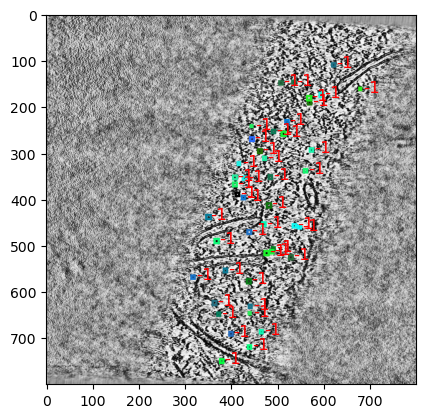

In [41]:
take = 287

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf 
subdf2 = subdf2[subdf2["z"] == take] 

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": list(subdf2['label_id'].astype(str))} 
utils.drawannotation(img, labels, font_size=12)
plt.show()
plt.close()

/tmp/ipykernel_1401993/1463276975.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


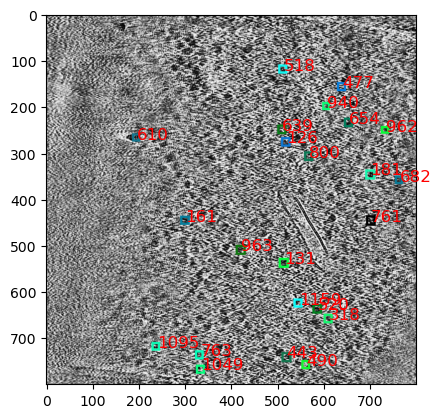

/tmp/ipykernel_1401993/1463276975.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


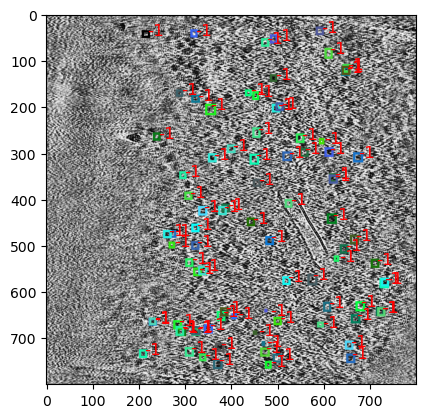

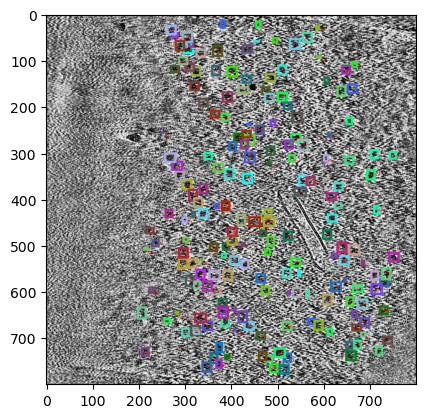

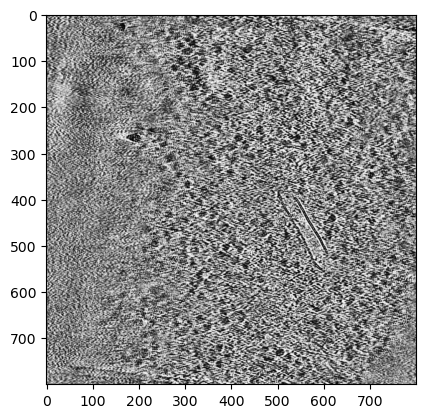

In [171]:
take = 287

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf 
subdf2 = subdf2[subdf2["z"] == take] 

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": list(subdf2['label_id'].astype(str))} 
utils.drawannotation(img, labels, font_size=12)
plt.show()
plt.close()

take = 287

# img = retdict["images"][take]
t = dataset.__getitem__(pos=take)# ["pixel_values"]
img2 = t["pixel_values"]
l = t["labels"]
# subdf2 = subdf.loc[need]
subdf2 = subdf_unlabeled 
subdf2 = subdf2[subdf2["z"] == take] 

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img2[0] = img2[1]
img2[2] = img2[1]
labels = {"bboxes": bboxes, "labels": list(subdf2['label_id'].astype(str))} 
utils.drawannotation(img2, labels, font_size=12)
plt.show()
plt.close()


utils.drawannotation(img, l, font_size=1, mask=False)
plt.show()
plt.close()


plt.imshow(img[1], cmap="gray")

In [ ]:
with open("/home/feity/cryoem/temp/results/sllt39_ribo_myscan.pkl", "wb") as f:
    pickle.dump({"df":df, "centers":centers, "roc":roc, "cnts":cnt}, f)

In [ ]:
res = {}
for i in range(len(centers)):
    pos = int(centers[i][0])
    subdf = df[df["z"] == pos]
    subdf["distance"] = np.sqrt((subdf["y"]*1024 - centers[i][1])**2 + (subdf["x"]*1024 - centers[i][2])**2)
    df_sorted = subdf.sort_values(by="distance").reset_index(drop=True)
    res[i] = df_sorted.head(5)
    # print(centers[i][0])
    # break

/tmp/ipykernel_3596786/631950195.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


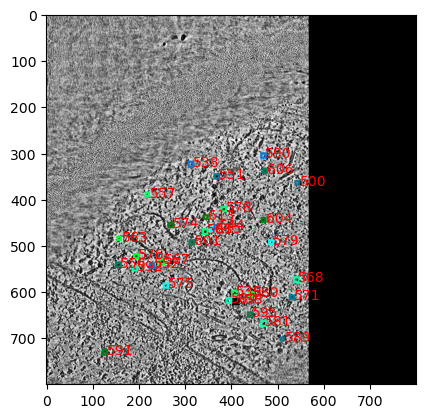

/tmp/ipykernel_3596786/631950195.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


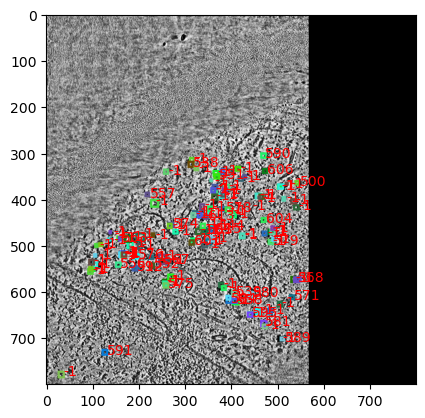

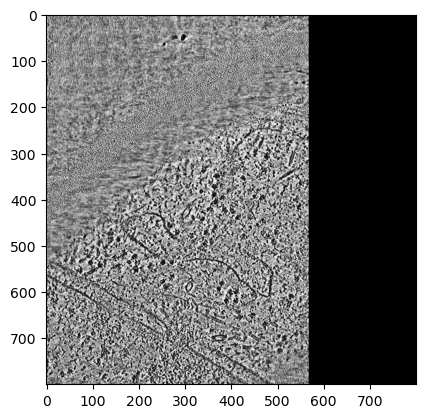

In [8]:
# take one slice and visualize
take = 287
q = df["z"]

subdf = df
# subdf = subdf[subdf["label_id"].isin(ids[400:500])]
subdf = subdf[(subdf["label"] != "")]
subdf = subdf[subdf["z"] == take]
# print(subdf["label_id"].value_counts())
# subdf = subdf[subdf["ribo"] > 0.8]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": list(subdf2['label_id'].astype(str))} 
utils.drawannotation(img, labels, font_size=10)
plt.show()
plt.close()

q = df["z"]

subdf = df
# subdf = subdf[(subdf["label"] != "")]
subdf = subdf[subdf["z"] == take]
subdf = subdf[subdf["None"] < 0.6]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]

img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": list(subdf2['label_id'].astype(str))} 
utils.drawannotation(img, labels, font_size=10)
plt.show()
plt.close()

t = dataset.__getitem__(pos=take)
# plt.imshow(t["pixel_values"][1], cmap="gray")
# # print(t["labels"])
# # print("yes")
plt.imshow(t["pixel_values"][1], cmap="gray")   
# utils.drawannotation(t["pixel_values"], t["labels"], mask=True, font_size=10)

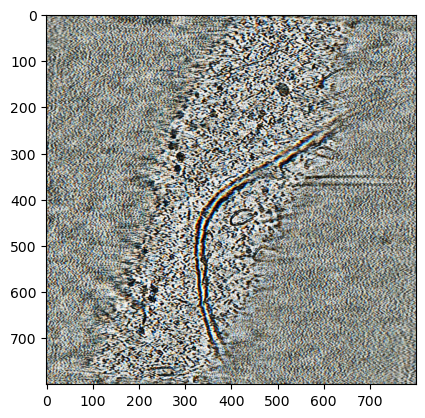

277.93454104024653 323.91707909235225 587.6853114203006
277.1365503080082 875.4360649617323 265.27272727272725
278.39344721366564 839.1858489685429 198.08260991318957
278.778402172895 639.4120071181044 256.7233305235553
280.29918394353774 208.02073224525805 655.3823334803706
281.3918352129742 169.09423058998973 683.8835865411502
279.8601196038124 208.3069519715941 477.4964492618202
280.39228686151836 327.2741619198805 354.87048277150063
281.5802711547452 426.77129499766244 365.26414212248716
286.52776742452477 276.1534662691017 463.8231457323891
282.63120567375887 314.05020530048523 410.5600970511385
284.9947663551402 278.11579439252336 371.4933644859813
284.0105469479186 738.8090349075975 236.67444465185739
285.70966237642233 397.90859914195113 373.0398246595784
288.22515875980577 754.8118229361226 482.9744116548375
289.7768032098535 365.4758794438742 353.43090417094334
291.14092646099357 276.580389598285 595.8134961319787
290.80920744830166 761.3778422382334 297.96425563769066
294.25

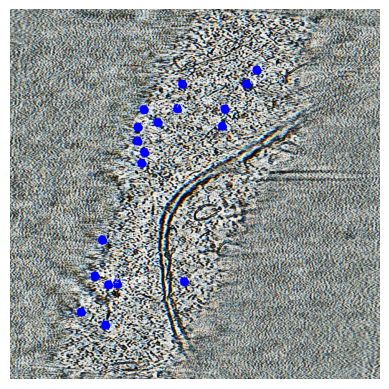

290.0 317.3713915275805 590.2895692767519
279.0 875.2461270419034 265.24674571644175
286.5 276.94280910491943 463.0897274017334
283.5 203.75462595621744 481.87437235514324
291.5 275.18695772611176 595.6985990084135
278.0 426.7105777624882 362.8260988177675
288.0 393.10549295359647 370.7125233617322
279.5 313.30907745361327 407.18382568359374
280.5 655.2701568603516 278.30562809535434
295.5 213.15919670691858 659.0130380483774
282.5 365.10237943209137 348.9167292668269
282.0 785.2631564670139 296.32605206524886
292.5 761.1260655721029 271.9132499694824
280.2692307692308 739.6011986365685 235.52678739107571
282.5 762.1409881591796 300.7670013427734
288.5 854.3330852801984 366.5852837195763
287.5 394.53601455688477 571.2467168172201
279.5 278.18480058149856 370.1383236971769
278.0 208.75831443385073 658.3447394120066
284.1363636363636 331.6680450439453 353.1981991854581
284.5 670.8369750976562 349.8812059674944
291.0 239.60247215857873 436.55182589017426
290.0 706.526200358073 255.7258616

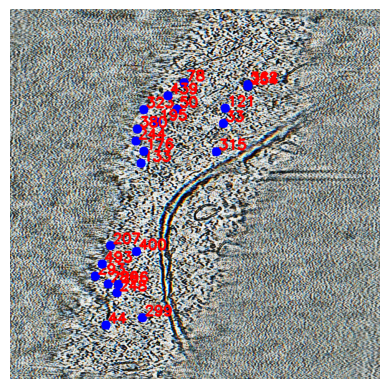

In [125]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

take = 287
img = dataset.__getitem__(pos=take)["pixel_values"]
img = img.numpy().transpose(1, 2, 0)
img = (img - img.min()) / (img.max() - img.min()) * 255
img = img.astype(np.uint8)
img = img.copy()
plt.imshow(img)
plt.show()
plt.close()

# Example: your image array of shape (3, 800, 800)
# image_array = your_image_array
# Simulating a random image here for demonstration
# image_array = np.random.randint(0, 255, (3, 800, 800), dtype=np.uint8)

# Transpose from (C, H, W) -> (H, W, C)
# image_array = np.transpose(image_array, (1, 2, 0)).copy()

image_array = img.copy()

# Example label points
# points = [(100, 150), (250, 400), (500, 600)]
points = []
for z, y, x in centers:
    if abs(z - take) < 10:
        print(z, y, x)
        points.append((int(x/1024*800), int(y/1024*800)))
# Draw points
for (x, y) in points:
    cv2.circle(image_array, (x, y), 10, (255, 0, 0), -1)  # Blue points
    cv2.putText(image_array, f"({x},{y})", (x+5, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Show using matplotlib (avoids CV2 window issues)
plt.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

image_array = img.copy()

# Example label points
# points = [(100, 150), (250, 400), (500, 600)]
points = []
for i, (z, y, x) in enumerate(predict_center):
    if abs(z - take) < 10:
        print(z, y, x)
        points.append((int(x/1024*800), int(y/1024*800)))
        x = int(x/1024*800) 
        y = int(y/1024*800)
# Draw points
# for i, (x, y) in enumerate(points):
        cv2.circle(image_array, (x, y), 10, (255, 0, 0), -1)  # Blue points
        cv2.putText(image_array, str(i), (x+5, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
    
# for (x, y) in points:
    # cv2.circle(image_array, (x, y), 10, (255, 0, 0), -1)  # Blue points
    # cv2.putText(image_array, f"({x},{y})", (x+5, y-5),
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Show using matplotlib (avoids CV2 window issues)
plt.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Simulate array from your case (C, H, W) = (3, 800, 800)
img = np.random.randint(0, 255, (3, 800, 800), dtype=np.uint8)

# Convert to (H, W, C) for OpenCV
img = np.transpose(img, (1, 2, 0)).copy()

# Example points
points = [(100, 150), (250, 400), (500, 600)]

# Draw
for (x, y) in points:
    cv2.circle(img, (int(x), int(y)), 5, (255, 0, 0), -1)
    cv2.putText(img, f"({x},{y})", (x+6, y-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Show in matplotlib
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [83]:
df

,z,x,y,w,h,ribo,None,max,largest,unlabeled,label,label_id,class_value
0,1,0.108189,0.122316,0.018699,0.019458,0.855295,0.144705,0.855295,ribo,True,,-1,0.855295
1,1,0.202588,0.088528,0.019798,0.019642,0.606326,0.393674,0.606326,ribo,True,,-1,0.606326
2,2,0.108787,0.123039,0.020735,0.021509,0.863027,0.136973,0.863027,ribo,True,,-1,0.863027
3,2,0.203481,0.089200,0.021783,0.021500,0.619470,0.380530,0.619470,ribo,True,,-1,0.619470
4,2,0.082224,0.096443,0.020590,0.020519,0.491488,0.508512,0.508512,None,True,,-1,0.491488
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39870,498,0.974272,0.713332,0.017200,0.017446,0.477180,0.522820,0.522820,None,True,,-1,0.477180
39871,498,0.800220,0.799087,0.012862,0.013181,0.308590,0.691410,0.691410,None,True,,-1,0.308590
39872,498,0.920543,0.925274,0.019843,0.019703,0.526820,0.473180,0.526820,ribo,True,,-1,0.526820
39873,498,0.898171,0.860724,0.020607,0.020783,0.584805,0.415195,0.584805,ribo,True,,-1,0.584805


In [73]:
model = model.cuda(1)

In [25]:
importlib.reload(postprocess)
importlib.reload(data)
mask_thres = {
    "ribo":0.75, 
    "hsp60":0.75, 
    "mitochondria":0.6,
    "nucleus":0.6,
    "endoplasmic_reticulum_or_Golgi":0.6,
    
}
prepare_mask_input = {
    "nucleus":{"class_id":2, "min_length": 50, "extend": 10}, 
    "mitochondria":{"class_id":1, "min_length": 40, "extend": 5}, 
    "endoplasmic_reticulum_or_Golgi":{"class_id":3, "min_length": 30, "extend": 5}, 
    "ribo":{"class_id":0, "min_length": 12, "extend": 0}, 
    "hsp60":{"class_id":0, "min_length": 12, "extend": 0}, 
}
refine_mask = {
    "nucleus":{"smooth": 2.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":True}, 
    "mitochondria":{"smooth": 2.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":False}, 
    "endoplasmic_reticulum_or_Golgi":{"smooth": 1.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (11, 11), "max_contours": 1, "contour_area_threshold":250, "apply_convex_hull":False}, 
    "ribo":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
    "hsp60":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
}
stage1_output = {}
build_masks = {
    "ribo": np.zeros((500, 800, 800), dtype=int),
    "hsp60": np.zeros((500, 800, 800), dtype=int),
    "mitochondria": np.zeros((500, 800, 800), dtype=int),
    "nucleus": np.zeros((500, 800, 800), dtype=int),
    "endoplasmic_reticulum_or_Golgi": np.zeros((500, 800, 800), dtype=int),
    
}
all_inputs = {}
for (label, label_id), r in df.groupby(["label", "label_id"]):
    if label != "hsp60":
        continue
    # if label == "":
    #     continue
    if label_id == -1:
        continue
    print(label, label_id, len(r))
    # if label == "ribo":
    #     continue
    if "%s_%s"%(label, label_id) in all_inputs:
        continue
    inputs, stage1_output = postprocess.getMaskInputs(r, model, dataset, **prepare_mask_input[label], stage1_outputs=stage1_output)
    # inputs = postprocess.getMaskInputsStage2(
    #     r,
    #     dataset, 
    #     **prepare_mask_input[label],
    #     res = res
    # )
    all_inputs["%s_%s"%(label, label_id)] = inputs
    smoothed_masks = postprocess.getMasks(model, inputs, refine_mask[label]["smooth"], on_z_only=True)

    minz = np.min(list(inputs.keys()))
    maxz = np.max(list(inputs.keys()))
    t = np.max(smoothed_masks)
    # masks = [] 
    for i in range(len(smoothed_masks)):
        mask = smoothed_masks[i]
        # box = inputs[i + minz]["input_mask"]
        # t1 = (mask * box).sum() / box.sum()
        # t2 = (mask * (1 - box)).sum() / (1 - box).sum()
        thres = t*mask_thres[label]
        refined_mask = postprocess.refineMask(
            mask,
            threshold = thres,
            **refine_mask[label],
        )
        smoothed_masks[i] = refined_mask
    smoothed_masks = smoothed_masks.astype(np.int32)
    
    for i in range(minz, maxz+1):
        build_masks[label][i][smoothed_masks[i-minz]>1] = (label_id+1)
        # masks.append(refined_mask)
    
    

hsp60 0 8
hsp60 1 12
hsp60 2 9
hsp60 3 8
hsp60 4 16
hsp60 5 5
hsp60 6 5
hsp60 7 6
hsp60 8 7
hsp60 9 17
hsp60 10 20
hsp60 11 11
hsp60 12 12
hsp60 13 18
hsp60 14 10
hsp60 15 8
hsp60 16 16
hsp60 17 17
hsp60 18 15
hsp60 19 23
hsp60 20 17
hsp60 21 12
hsp60 22 17
hsp60 23 8
hsp60 24 16
hsp60 25 15
hsp60 26 13
hsp60 27 12
hsp60 28 15
hsp60 29 17
hsp60 30 27
hsp60 31 30
hsp60 32 13
hsp60 33 16
hsp60 34 12
hsp60 35 19
hsp60 36 18
hsp60 37 13
hsp60 38 14
hsp60 39 24
hsp60 40 21
hsp60 41 11
hsp60 42 22
hsp60 43 6
hsp60 44 8
hsp60 45 8
hsp60 46 8
hsp60 47 6
hsp60 48 9
hsp60 49 11
hsp60 50 18
hsp60 51 10
hsp60 52 11
hsp60 53 15
hsp60 54 13
hsp60 55 23
hsp60 56 20
hsp60 57 22
hsp60 58 7
hsp60 59 14
hsp60 60 8
hsp60 61 22
hsp60 62 18
hsp60 63 24
hsp60 64 16
hsp60 65 29
hsp60 66 25
hsp60 67 10
hsp60 68 10
hsp60 69 12
hsp60 70 17
hsp60 71 11
hsp60 72 5
hsp60 73 29
hsp60 74 8
hsp60 75 13
hsp60 76 12
hsp60 77 20
hsp60 78 11
hsp60 79 6
hsp60 80 26
hsp60 81 13
hsp60 82 16
hsp60 83 19
hsp60 84 6
hsp60 85 7


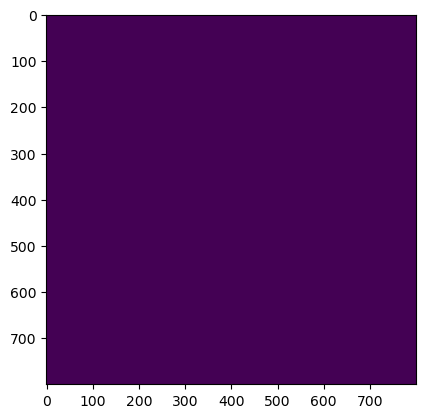

In [26]:
t = build_masks["hsp60"][225]
# t[t > 499] = 0
plt.imshow(t)

In [27]:
subdf = df[df["label_id"] != -1]
t = subdf["label_id"].value_counts()

In [30]:
labels, centers = get_labels_and_centers(build_masks["hsp60"])

In [204]:
labels

array([   3,    4,    5,    6,    7,    8,    9,   10,   11,   13,   14,
         15,   16,   17,   18,   19,   20,   21,   22,   23,   24,   25,
         27,   29,   30,   31,   33,   34,   36,   37,   38,   39,   40,
         41,   42,   43,   44,   45,   46,   47,   48,   49,   50,   51,
         52,   53,   54,   55,   56,   57,   58,   59,   60,   62,   63,
         64,   65,   66,   67,   68,   69,   70,   71,   72,   73,   74,
         75,   76,   77,   78,   79,   80,   81,   82,   83,   84,   85,
         87,   88,   89,   90,   91,   92,   93,   94,   95,   96,   97,
         98,  100,  101,  102,  104,  105,  108,  109,  111,  112,  113,
        116,  117,  118,  119,  120,  121,  122,  123,  125,  126,  128,
        129,  130,  131,  132,  135,  136,  137,  138,  139,  140,  141,
        142,  143,  144,  147,  148,  150,  151,  153,  154,  155,  156,
        157,  159,  160,  161,  162,  163,  164,  165,  166,  167,  168,
        170,  172,  174,  175,  176,  177,  178,  1

In [31]:
masks = {} 
from scipy.sparse import csr_matrix
for i in range(500):
    masks[i] = csr_matrix(build_masks["hsp60"][i])
with open("/home/feity/cryoem/temp/results/hsp60_24092002_new.pkl", "wb") as f:
    pickle.dump({
        "centers":{i:j for i, j in zip(labels, centers)},
        "df": df, 
        "masks": masks, 
        # "inputs": all_inputs
    }, f)


In [132]:
predict_center

array([[194.        ,  84.43543012, 433.94368952],
       [152.        ,  99.7940119 , 199.67883763],
       [100.        , 101.06685222,  61.05786954],
       ...,
       [361.5       , 687.48418172, 797.56280518],
       [480.5       , 883.49634298, 912.12565613],
       [419.7       , 747.38770752, 752.77404785]])

In [131]:
centers

array([[195.25263541,  64.92784442, 339.24500182],
       [143.31313559,  82.59491525, 153.90805085],
       [ 97.42143362,  80.23764124,  49.23975989],
       ...,
       [362.41249499, 536.42130557, 623.31637966],
       [478.25667609, 690.87496073, 712.11027333],
       [423.51237176, 587.16294508, 589.12914906]])

In [135]:
centers_1024 = centers.copy()
centers_1024[:, 1] = centers[:, 1] / 800 * 1024
centers_1024[:, 2] = centers[:, 2] / 800 * 1024

In [136]:
centers_1024

array([[195.25263541,  83.10764086, 434.23360233],
       [143.31313559, 105.72149153, 197.00230508],
       [ 97.42143362, 102.70418079,  63.02689266],
       ...,
       [362.41249499, 686.61927113, 797.84496596],
       [478.25667609, 884.31994973, 911.50114986],
       [423.51237176, 751.5685697 , 754.0853108 ]])

In [ ]:
with open("/home/feity/cryoem/temp/results/sllt39_1.pkl", "wb") as f:
    pickle.dump({
        "df": df, 
        "masks": build_masks, 
        "inputs": all_inputs
    }, f)

In [ ]:
with open("/home/feity/cryoem/temp/results/sllt39_1.pkl", "rb") as f:
    d = pickle.load(f)
d["masks"]["ribo"] = build_masks["ribo"]
with open("/home/feity/cryoem/temp/results/sllt39_1.pkl", "wb") as f:
    pickle.dump(d, f)

In [ ]:
df = df[df["label"] != ""] 
df = df[df["label"] != "endoplasmic_reticulum_or_Golgi"]
df

In [ ]:
plt.imshow(d["masks"]["mitochondria"][280])

In [ ]:
plt.imshow(build_masks["hsp60"][200])